We are trying to investigate how Women's health in the years 2011-2013 has either decreased or increased throughout the year.

In [1]:
# importing necessary libraries
import pandas as pd

# fetching the url where the dataset is located
# Pre-cleaned version on Kaggle (requires Kaggle API key)
# OR use this CDC direct CSV — age-adjusted prevalence, no login:
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"


# loading the dataset
df = pd.read_csv(url)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# displaying 5 random values
df.sample(5)

Shape: 86481 rows × 27 columns


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
62040,2020,WV,West Virginia,Women's Health,Mammogram,Women aged 40+ who have had a mammogram within...,No,Overall,Overall,647,...,NaN,BRFSS,CLASS18,TOPIC37,54,BO1,CAT1,_RFMAM22,RESP054,"(38.66551020200046, -80.71264013499967)"
73559,2022,VT,Vermont,Chronic Health Indicators,Kidney,Ever told you have kidney disease?,No,Overall,Overall,8521,...,NaN,BRFSS,CLASS03,TOPIC35,50,BO1,CAT1,CHCKDNY2,RESP054,"(43.62538123900049, -72.51764079099962)"
48151,2018,SC,South Carolina,Chronic Health Indicators,Cardiovascular Disease,Ever told you had a heart attack (myocardial i...,Yes,Overall,Overall,764,...,NaN,BRFSS,CLASS03,TOPIC10,45,BO1,CAT1,CVDINFR4,RESP046,"(33.998821303000454, -81.04537120699968)"
1079,2011,DC,District of Columbia,Tobacco Use,Smoker Status,Four Level Smoking Status (variable calculated...,Smoke some days,Overall,Overall,294,...,NaN,BRFSS,CLASS17,Topic55,11,BO1,CAT1,_SMOKER3,RESP069,"(38.890371385, -77.031961127)"
22639,2014,WI,Wisconsin,Demographics,Disability status,"Do you have serious difficulty concentrating, ...",No,Overall,Overall,6198,...,NaN,BRFSS,CLASS05,Topic19,55,BO1,CAT1,DECIDE,RESP054,"(44.393191174, -89.816370742)"


**I observed that the data shows that there is a wide range of years from 2011 to 2024, revealing how we can identify the trends and changes over more than a decade, in the class column there is a duplicate: Depression, and the question column provides specific and detailed inquiries about various health conditions. Not only that but, the location column clearly represents the lists of US states and territories and the response column captures a wide array of responses ranging from simply "YES/NO" to specific categories. **

In [ ]:
df.columns
df['Sample_Size'].unique()

array([  184,   260,  1782, ..., 11880, 10922, 11700])

In [ ]:
df.columns
df['Topic'].unique()

array(['Blood Stool Test', 'USPSTF Recommendations',
       'Alcohol Consumption', 'Cardiovascular Disease', 'Kidney', 'COPD',
       'Veteran Status', 'Healthy Days', 'Diabetes',
       'Fair or Poor Health', 'Overall Health', 'HIV Test', 'Flu Shot',
       'Pneumonia Vaccination', 'Other Cancer', 'Skin Cancer',
       'Disability status', 'All Teeth Removed', 'Dental Visit',
       'Teeth Removed', 'BMI Categories', 'Exercise',
       'Current Smoker Status', 'Smokeless Tobacco', 'Smoker Status',
       'Binge Drinking', 'Heavy Drinking', 'Cholesterol Checked',
       'Cholesterol High', 'Arthritis', 'Asthma', 'Depression', 'Vision',
       'Health Care Coverage', 'Under 65 Coverage', 'High Blood Pressure',
       'Seatbelt Use', 'Aerobic Activity', 'Physical Activity Index',
       'Strength Activity', 'Hearing', 'Sigmoidoscopy', 'Drink and Drive',
       'PSA Test', 'Mammogram', 'Pap Test', 'Internet',
       'Fruit Consumption', 'Vegetable Consumption', 'Health Care Cost',
       

In [ ]:
df.columns
df['Class'].unique()

array(['Colorectal Cancer Screening', 'Alcohol Consumption',
       'Chronic Health Indicators', 'Demographics', 'Days of Poor Health',
       'Health Status', 'HIV-AIDS', 'Immunization', 'Oral Health',
       'Overweight and Obesity (BMI)', 'Physical Activity', 'Tobacco Use',
       'Cholesterol Awareness', 'Health Care Access/Coverage',
       'Hypertension Awareness', 'Injury', 'Prostate Cancer',
       "Women's Health", 'Fruits and Vegetables', 'E-Cigarette Use',
       'Lung Cancer Screening'], dtype=object)

In [ ]:
df.columns
df['Locationdesc'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming', 'Guam', 'Puerto Rico',
       'Virgin Islands'], dtype=object)

In [ ]:
df.columns
df['Year'].unique()

array([2022, 2024, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2023])

In [ ]:
#Nirvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization

url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

print(f"Initial raw dataset shape: {df.shape}")

Initial raw dataset shape: (86481, 27)


In [ ]:
df.columns
df['Response'].unique()

array(['Had a blood stool test in the past year',
       'Have not had a blood stool test in more than the past year',
       'Received one or more of the recommended CRC tests within the recommended time interval',
       'Did not receive one or more of the recommended CRC tests within the recommended time interval',
       'Have never received any of the recommended CRC tests', 'No',
       'Yes', '14+ days when mental health not good',
       'Fair or Poor Health', 'Excellent', 'Very good', 'Good', 'Fair',
       'Poor', 'Obese (BMI 30.0 - 99.8)', 'Overweight (BMI 25.0-29.9)',
       'Normal Weight (BMI 18.5-24.9)', 'Underweight (BMI 12.0-18.4)',
       'Every day', 'Some days', 'Not at all', 'Smoke everyday',
       'Smoke some days', 'Former smoker', 'Checked in past 5 years',
       'Not Checked in past 5 years', 'Never Checked',
       'Yes, pregnancy-related',
       'No, pre-diabetes or borderline diabetes', 'Respondent is blind',
       'Good or Better Health', 'Always Wears 

In [ ]:
df.isnull().sum()

,0
Year,0
Locationabbr,0
Locationdesc,0
Class,0
Topic,0
Question,0
Response,0
Break_Out,0
Break_Out_Category,0
Sample_Size,0


Unique years in the filtered data for Women's Health: [2012]


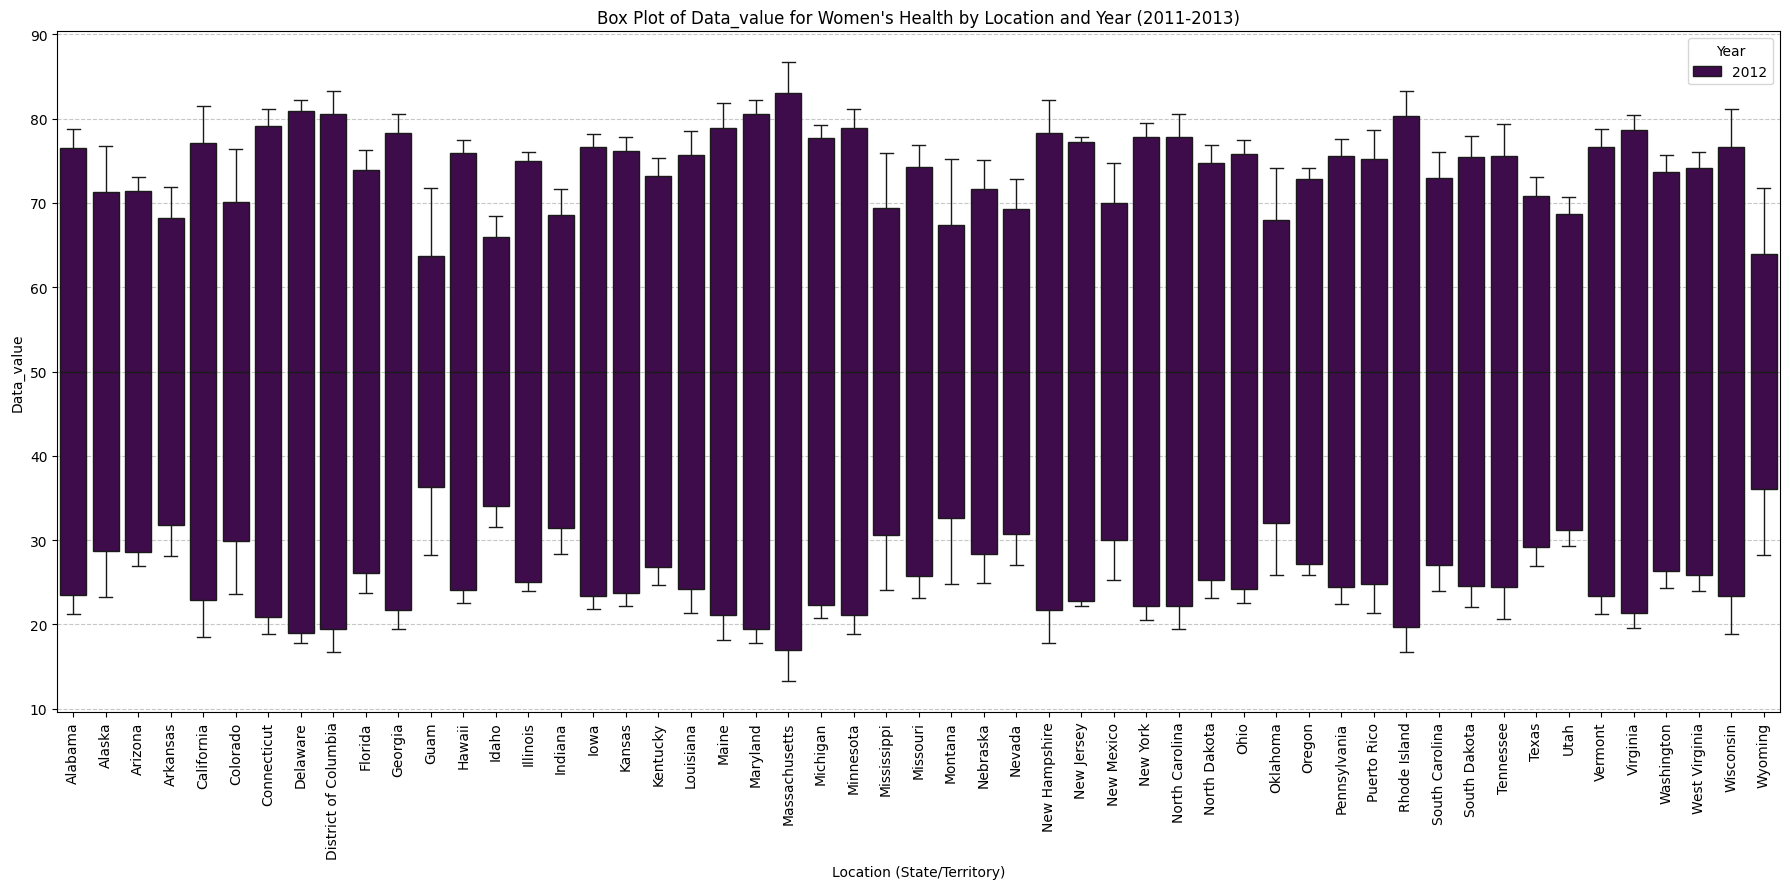

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for 'Women's Health' class and specified years (2011-2013)
filtered_womens_health_data = df[
    (df['Class'] == "Women's Health") &
    (df['Year'].isin([2011, 2012, 2013]))
].copy()

# Check if the filtered DataFrame is empty
if not filtered_womens_health_data.empty:
    print(f"Unique years in the filtered data for Women's Health: {filtered_womens_health_data['Year'].unique()}")

    plt.figure(figsize=(18, 9)) # Make figure wider to accommodate many locations
    sns.boxplot(data=filtered_womens_health_data, x='Locationdesc', y='Data_value', palette='viridis', hue='Year')
    plt.title("Box Plot of Data_value for Women's Health by Location and Year (2011-2013)")
    plt.xlabel('Location (State/Territory)')
    plt.ylabel('Data_value')
    plt.xticks(rotation=90) # Rotate x-axis labels for readability
    plt.legend(title='Year')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 'Women's Health' in the years 2011, 2012, and 2013 to generate a box plot by location.")

**I have observed that there are multiple box plots which display more diversed data values across different geological locations, there is no consistency in the average sample size across all 3 years, and there is a visual similarity in the colors. Moreover, there is no significant trend in the sample meaning that there was no increase or decrease throughout the years.  **

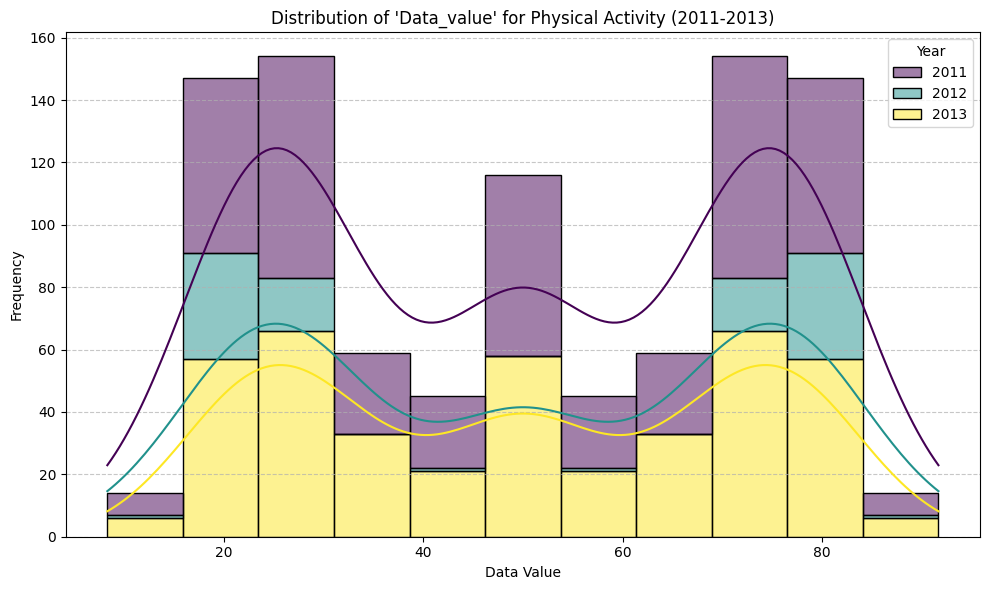

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for 'Physical Activity' and specified years (2011-2013)
filtered_health_data = df[
    (df['Class'] == "Physical Activity") &
    (df['Year'].isin([2011, 2012, 2013]))
].copy()

# Check if the filtered DataFrame is empty
if not filtered_health_data.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=filtered_health_data, x='Data_value', hue='Year', kde=True, palette='viridis', multiple='stack')
    plt.title("Distribution of 'Data_value' for Physical Activity (2011-2013)")
    plt.xlabel('Data Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 'Physical Activity' in the years 2011, 2012, and 2013 to generate a histogram.")

**I have observed that the Frequency is the y-values and the Data value is the x-values. Not only that but, the lines represent KDE(Kernel Density Estimate). The color represents the years between 2011-2013 which is correct because my years were from 2011-2013.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Filter data for 'Cardiovascular Disease' and specified years (2011-2013)
filtered_cardiovascular_data = df[
    (df['Topic'] == "Cardiovascular Disease") &
    (df['Year'].isin([2011, 2012, 2013]))
].copy()

# Drop rows where 'Data_value' is null, as this is our target variable
filtered_cardiovascular_data.dropna(subset=['Data_value'], inplace=True)

# Define features (X) and target (y)
# Use 'Year' and 'Sample_Size' as numerical features
# Use 'Locationdesc', 'Class', 'Question', 'Response' as categorical features
features = ['Year', 'Sample_Size', 'Locationdesc', 'Class', 'Question', 'Response']
X_cardio = filtered_cardiovascular_data[features]
y_cardio = filtered_cardiovascular_data['Data_value']

# Convert categorical features to numerical using one-hot encoding
X_cardio = pd.get_dummies(X_cardio, columns=['Locationdesc', 'Class', 'Question', 'Response'], drop_first=True)

# Split the data into training and testing sets
X_cardio_train, X_cardio_test, y_cardio_train, y_cardio_test = train_test_split(X_cardio, y_cardio, test_size=0.2, random_state=42)

print(f"Shape of training features for Cardiovascular Disease: {X_cardio_train.shape}")
print(f"Shape of testing features for Cardiovascular Disease: {X_cardio_test.shape}")
print(f"Shape of training target for Cardiovascular Disease: {y_cardio_train.shape}")
print(f"Shape of testing target for Cardiovascular Disease: {y_cardio_test.shape}")

Shape of training features for Cardiovascular Disease: (763, 57)
Shape of testing features for Cardiovascular Disease: (191, 57)
Shape of training target for Cardiovascular Disease: (763,)
Shape of testing target for Cardiovascular Disease: (191,)


Linear Regression Model Evaluation for Cardiovascular Disease (2011-2013):
Mean Squared Error (MSE): 1.0866
R-squared (R2): 0.9995


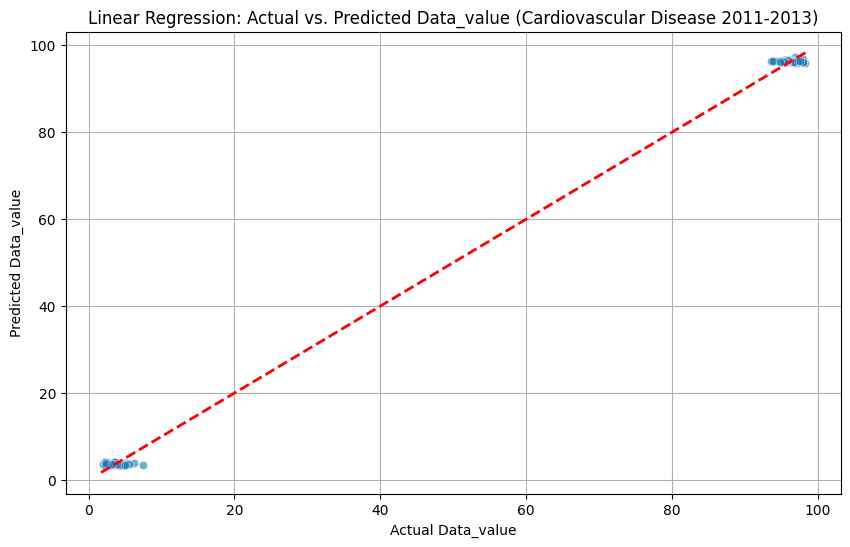

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set for Cardiovascular Disease
y_cardio_pred = linear_model_cardio.predict(X_cardio_test)

# Evaluate the model
mse_cardio = mean_squared_error(y_cardio_test, y_cardio_pred)
r2_cardio = r2_score(y_cardio_test, y_cardio_pred)

print(f"Linear Regression Model Evaluation for Cardiovascular Disease (2011-2013):")
print(f"Mean Squared Error (MSE): {mse_cardio:.4f}")
print(f"R-squared (R2): {r2_cardio:.4f}")

# Visualize actual vs. predicted values for Cardiovascular Disease
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_cardio_test, y=y_cardio_pred, alpha=0.6)
plt.plot([y_cardio.min(), y_cardio.max()], [y_cardio.min(), y_cardio.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual Data_value")
plt.ylabel("Predicted Data_value")
plt.title("Linear Regression: Actual vs. Predicted Data_value (Cardiovascular Disease 2011-2013)")
plt.grid(True)
plt.show()

**I observed that as the predicated data values increase, the number of actual data values increase. Not only that but, the line chart is getting better over time. All the data points cluster very closely around the red dashed line.**

Unique years in filtered 'Demographics' data (2011-2013): [2011 2012 2013]
Unique 'Topic' categories in filtered 'Demographics' data (2011-2013): ['Disability status' 'Internet' 'Veteran Status']


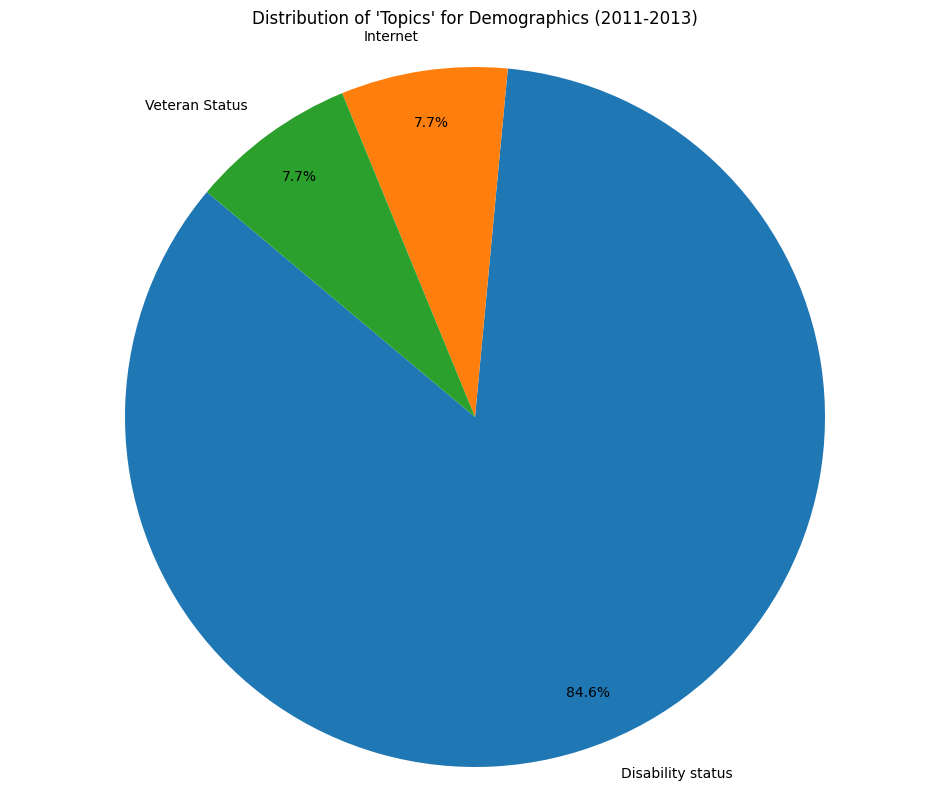

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset again to ensure 'df' is defined in this execution context
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Filter data for 'Demographics' and specified years (2011-2013)
filtered_demographics_topic_data = df[
    (df['Class'] == "Demographics") &
    (df['Year'].isin([2011, 2012, 2013]))
].copy()

# Drop rows where 'Data_value' is null, to maintain consistency with previous analyses.
filtered_demographics_topic_data.dropna(subset=['Data_value'], inplace=True)

print(f"Unique years in filtered 'Demographics' data (2011-2013): {filtered_demographics_topic_data['Year'].unique()}")
print(f"Unique 'Topic' categories in filtered 'Demographics' data (2011-2013): {filtered_demographics_topic_data['Topic'].unique()}")

if filtered_demographics_topic_data.empty:
    print("No data available for 'Demographics' in the years 2011, 2012, and 2013 after dropping nulls. Cannot generate a pie chart for topics.")
else:
    # Count the occurrences of each 'Topic' for the Demographics class
    topic_counts_demographics = filtered_demographics_topic_data['Topic'].value_counts()

    # Plotting the pie chart
    fig = plt.figure(figsize=(12, 10))
    plt.pie(topic_counts_demographics, labels=topic_counts_demographics.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
    plt.title("Distribution of 'Topics' for Demographics (2011-2013)")
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

I observed that percentages for the 2 topics: Internet and Veternan Status are the same, the Disability status topic represents the overwhelming majority of the data, and the visual size of the Disability status slice is significantly larger than the combined slices. Not only that but, the visual absense of any other topics shows how these 3 topics are the only revelant ones in the Demographics class for the years 2011-2013.

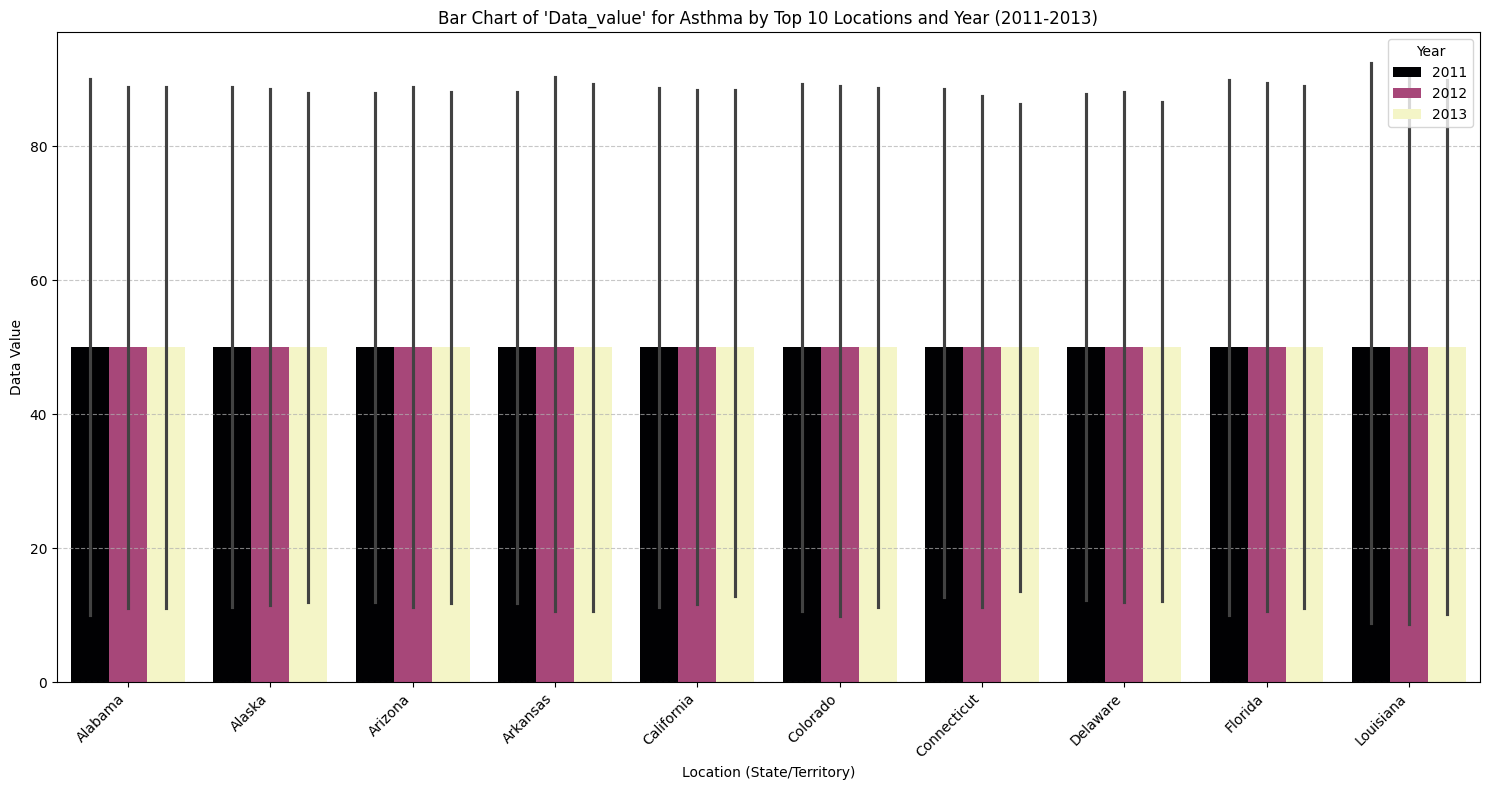

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 'Asthma' topic and specified years (2011-2013)
filtered_asthma_data = df[
    (df['Topic'] == 'Asthma') &
    (df['Year'].isin([2011, 2012, 2013]))
].copy()

# Drop rows where 'Data_value' is null
filtered_asthma_data.dropna(subset=['Data_value'], inplace=True)

if filtered_asthma_data.empty:
    print("No data available for 'Asthma' in the years 2011, 2012, and 2013 after dropping nulls. Cannot generate a bar chart.")
else:
    # Calculate the average Data_value for each location to identify top locations
    average_data_value_by_location = filtered_asthma_data.groupby('Locationdesc')['Data_value'].mean().sort_values(ascending=False)

    # Select the top 10 locations
    top_10_locations = average_data_value_by_location.head(10).index

    # Filter the original data to include only the top 10 locations
    filtered_asthma_data_top_10 = filtered_asthma_data[filtered_asthma_data['Locationdesc'].isin(top_10_locations)]

    # Create a bar chart for the top 10 locations
    fig = plt.figure(figsize=(15, 8)) # Adjust figure size
    sns.barplot(data=filtered_asthma_data_top_10, x='Locationdesc', y='Data_value', hue='Year', palette='magma')

    plt.title("Bar Chart of 'Data_value' for Asthma by Top 10 Locations and Year (2011-2013)")
    plt.xlabel('Location (State/Territory)')
    plt.ylabel('Data Value')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.legend(title='Year')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

I observed that the chart focuses on 10 locations which suggests the areas with the highest average data value for Asthma, the 3 colors shown represent the years 2011-2013, and the data value appears to around the same range. Additionally, there doesn't appear to be a upward or downward trend for the data value.